In [1]:
##modules
#%matplotlib widget
#%matplotlib inline
#
%matplotlib qt
import mne
import numpy as np
import matplotlib
# Establecer un backend interactivo, como 'Qt5Agg', 'GTK3Agg', etc.
# Esto depende de los backends disponibles en tu sistema.

import matplotlib.pyplot as plt

#matplotlib.use('TkAgg')  # Asegúrate de que este backend está instalado.

import pandas as pd 
import os
import sys

from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs

from os.path import join as pathjoin
from time import time

from pathlib import Path

from autoreject import AutoReject

# aplicar la acf EN epochs

from statsmodels.tsa.stattools import acf
import numpy as np

import pandas as pd


import os, re, warnings
import numpy as np
import pandas as pd
import mne
from scipy.sparse import csr_matrix


import pickle
from scipy.sparse import triu


In [2]:

try:
    # Si se ejecuta como SCRIPT .py: usar __file__
    sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
except NameError:
    # Si se ejecuta como NOTEBOOK Jupyter: usar path relativo
    sys.path.append("..")  # sube un nivel desde la carpeta actual del notebook


# --- Configuración dinámica de rutas ---
from get_paths_SELF import get_paths_SELF

# Parámetros editables
disco = "g"
modality="visual"
layer_script = "event"
subj= "s01b"


# Generar variables automáticamente
path_dict = get_paths_SELF(disco=disco, modality=modality,layer_script=layer_script,  subj=subj)
globals().update(path_dict)

# Mostrar todos los paths generados
print("\n📁 Rutas generadas:")
for k, v in path_dict.items():
    print(f"{k:<20} → {v}")

    

✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\ICA_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_clean_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_matlab_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\evoked_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\channels_structure
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_source\source_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_source\source_event\raw_hsp
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_source\source_event\fwd
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_source\source_event\inverse
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_analysis\analysis_event\acw_event
✅ Carpeta creada: g:\PROYECTO_SELF\SELF_visual\output_analysis\analysis_eve

# LECTURA EPOCHS

In [3]:
# Construimos lista subj_epochs_block a partir de archivos .fif
subj_epochs_block = []
pattern = re.compile(r"^(.*?)_epochs_")
type_epoch="self"

for fname in os.listdir(epochs_clean_path):
    if fname.endswith("-epo.fif"):
        match = pattern.match(fname)
        if match:
            subj_epochs_block.append(match.group(1))

subj_epochs_block = list(set(subj_epochs_block))

print("\nSujetos encontrados en epochs_clean_path:")
print(subj_epochs_block)
print(len(subj_epochs_block))


Sujetos encontrados en epochs_clean_path:
['S21b', 's07b', 's13b', 's16b', 's15b', 'S23b', 's32b', 'S24b', 's01b', 'S27b', 'S34b', 'S20b', 'S33b', 'S29b', 's05b', 's17b', 'S35b', 'S25b', 's06b', 'S30b', 's09b', 'S31b', 'S22b', 'S28b', 's03b', 's04b', 's14b', 's02b', 's36b', 'S26b', 'S19b', 's18b', 's12b', 's08b', 's10b', 's11b']
36


In [4]:



# Diccionarios para guardar info
all_ch_sets = {}
all_ch_names = {}
all_adjacencies = {}

# Diccionarios para guardar info
all_ch_sets = {}
all_ch_names = {}
all_adjacencies = {}
type_epoch="emoc"

for subj in subj_epochs_block:
    
    # Archivo único con todas las condiciones
    fname = epochs_clean_path / f"{subj}_epochs_{type_epoch}-epo.fif"
    
    if not fname.exists():
        warnings.warn(f"⚠️ Archivo no encontrado: {fname}")
        continue

    # Cargar epochs del sujeto
    epochs = mne.read_epochs(fname, preload=True)

    # Seleccionar solo magnetómetros y quitar bads
    epochs_mag_clean = epochs.pick(picks="eeg", exclude='bads')

    # Canales realmente presentes y válidos
    canales_efectivos = set(epochs_mag_clean.ch_names)

    # Obtener adyacencia de todos los magnetómetros del sensor layout
    adjacency, ch_names_total = mne.channels.find_ch_adjacency(
        epochs_mag_clean.info, ch_type='eeg'
    )
    ch_names_total_str = [str(ch) for ch in ch_names_total]

    # Guardar info usando solo la clave del sujeto
    all_ch_sets[subj] = canales_efectivos
    all_ch_names[subj] = ch_names_total_str
    all_adjacencies[subj] = adjacency

    del epochs, epochs_mag_clean
# --- Comprobación de consistencia ---
ref_key = next(iter(all_ch_names.keys()))

# Lista ordenada de canales.
# NO convertir a set, porque el orden debe coincidir con la matriz adjacency.
ref_channels = all_ch_names[ref_key]

ref_adjacency = all_adjacencies[ref_key]

warnings_flag = False

for key, chs in all_ch_names.items():
    # set solo para detectar canales faltantes o sobrantes
    diff1 = set(chs) - set(ref_channels)
    diff2 = set(ref_channels) - set(chs)

    if diff1 or diff2:
        warnings.warn(f"⚠️ Diferencia de canales en {key}: {diff1} {diff2}")
        warnings_flag = True

    # lista contra lista para comprobar que el orden sea idéntico
    elif chs != ref_channels:
        warnings.warn(f"⚠️ Mismos canales pero distinto orden en {key}")
        warnings_flag = True

if warnings_flag:
    print("❌ No se puede crear adjacency_reducida porque hay diferencias de canales u orden.")
    adjacency_reducida = None

else:
    print("✅ Todos los sujetos/condiciones tienen los mismos canales y el mismo orden.")

    # OJO: esto usa los canales efectivos del sujeto de referencia
    canales_efectivos = set.intersection(*all_ch_sets.values())

    df_canales = pd.DataFrame({
        "indice": range(len(ref_channels)),
        "nombre_base": ref_channels
    })

    df_canales["canal_efectivo"] = df_canales["nombre_base"].apply(
        lambda ch: ch if ch in canales_efectivos else np.nan
    )

    indices_efectivos = df_canales.loc[
        df_canales["canal_efectivo"].notna(),
        "indice"
    ].to_list()

    adjacency_reducida = ref_adjacency[indices_efectivos, :][:, indices_efectivos]

    print(f"✅ adjacency_reducida global creada con forma: {adjacency_reducida.shape}")
    
        # Create reduced channel table
    # ------------------------------------------------------------
    # This table maps each row/column of adjacency_reducida
    # to its corresponding channel name.

    df_canales_reducida = df_canales.loc[
        df_canales["indice"].isin(indices_efectivos)
    ].copy()

    df_canales_reducida = df_canales_reducida.reset_index(drop=True)

    df_canales_reducida["indice_adjacency_reducida"] = df_canales_reducida.index

    print(f"✅ df_canales_reducida created with shape: {df_canales_reducida.shape}")

Reading g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_clean_event\S21b_epochs_emoc-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    6000.00 ms
        0 CTF compensation matrices available
Not setting metadata
200 matching events found
No baseline correction applied
0 projection items activated
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 59
Reading g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_clean_event\s07b_epochs_emoc-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    6000.00 ms
        0 CTF compensation matrices available
Not setting metadata
268 matching events found
No baseline correction applied
0 projection items activated
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 59
Reading g:\PROYECTO_SELF\SELF_visual\output_

In [5]:
df_canales_reducida

,indice,nombre_base,canal_efectivo,indice_adjacency_reducida
0,0,Fp1,Fp1,0
1,1,Fpz,Fpz,1
2,2,Fp2,Fp2,2
3,3,AF7,AF7,3
4,4,AF3,AF3,4
5,5,AF4,AF4,5
6,6,AF8,AF8,6
7,7,F7,F7,7
8,8,F5,F5,8
9,9,F3,F3,9


Reading g:\PROYECTO_SELF\SELF_visual\output_preproc\preproc_event\epochs_clean_event\s11b_epochs_emoc-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    6000.00 ms
        0 CTF compensation matrices available
Not setting metadata
189 matching events found
No baseline correction applied
0 projection items activated


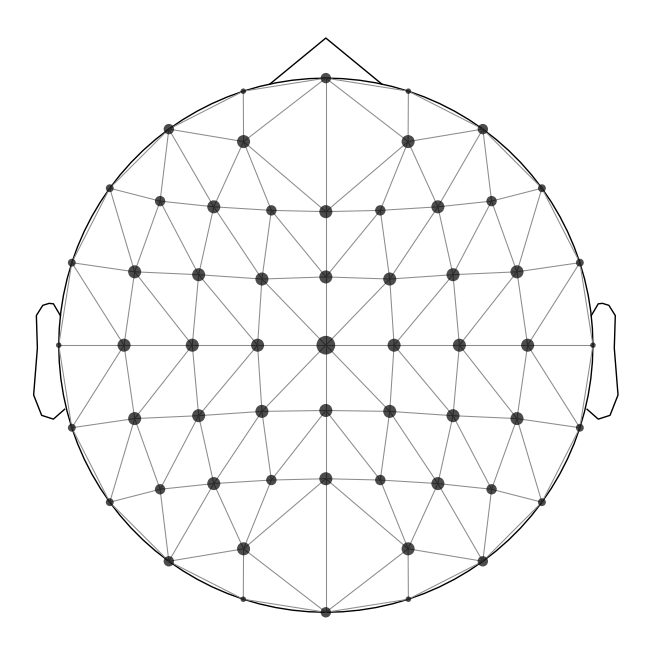

In [6]:
epochs = mne.read_epochs(fname, preload=True)
# Nombres de canales en el mismo orden que adjacency_reducida
ch_names_reducida = df_canales_reducida["nombre_base"].tolist()
mne.viz.plot_ch_adjacency(
    epochs.info,
    adjacency=adjacency_reducida,
    ch_names=ch_names_reducida
)

In [7]:
# Asegurar formato sparse
adj = adjacency_reducida

# Número total de entradas no cero
n_nonzero = adj.nnz

# Si la matriz incluye la diagonal, contamos la diagonal
n_diag = adj.diagonal().sum()

# Conexiones únicas entre canales
# Dividimos entre 2 porque la matriz es simétrica: A-B y B-A
n_conexiones_unicas = int((n_nonzero - n_diag) / 2)

print(f"Entradas no cero totales en adjacency: {n_nonzero}")
print(f"Elementos en la diagonal: {int(n_diag)}")
print(f"Conexiones únicas entre canales: {n_conexiones_unicas}")

Entradas no cero totales en adjacency: 367
Elementos en la diagonal: 59
Conexiones únicas entre canales: 154


In [8]:
ch_names_reducida = df_canales_reducida["nombre_base"].tolist()

# Número de vecinos por canal
# Restamos la diagonal si está incluida
n_vecinos = np.array(adjacency_reducida.sum(axis=1)).ravel()
diag = adjacency_reducida.diagonal()

n_vecinos_sin_diagonal = n_vecinos - diag

df_vecinos = pd.DataFrame({
    "canal": ch_names_reducida,
    "n_vecinos": n_vecinos_sin_diagonal.astype(int)
}).sort_values("n_vecinos", ascending=False)

print(df_vecinos)
print(f"\nPromedio de vecinos por canal: {df_vecinos['n_vecinos'].mean():.2f}")
print(f"Mínimo de vecinos: {df_vecinos['n_vecinos'].min()}")
print(f"Máximo de vecinos: {df_vecinos['n_vecinos'].max()}")

   canal  n_vecinos
29    Cz          8
5    AF4          6
9     F3          6
19   FC1          6
20   FCz          6
21   FC2          6
22   FC4          6
18   FC3          6
17   FC5          6
13    F4          6
4    AF3          6
23   FC6          6
26    C5          6
49    P4          6
41   CP6          6
38   CPz          6
37   CP1          6
40   CP4          6
39   CP2          6
35   CP5          6
36   CP3          6
32    C6          6
31    C4          6
30    C2          6
28    C1          6
27    C3          6
11    Fz          6
53   PO3          6
54   PO4          6
47    Pz          6
45    P3          6
57    Oz          5
46    P1          5
52   PO7          5
50    P6          5
6    AF8          5
8     F5          5
1    Fpz          5
3    AF7          5
10    F1          5
12    F2          5
48    P2          5
14    F6          5
55   PO8          5
44    P5          5
34   TP7          4
43    P7          4
16   FT7          4
7     F7          4


In [10]:
df_canales

,indice,nombre_base,canal_efectivo
0,0,Fp1,Fp1
1,1,Fpz,Fpz
2,2,Fp2,Fp2
3,3,AF7,AF7
4,4,AF3,AF3
5,5,AF4,AF4
6,6,AF8,AF8
7,7,F7,F7
8,8,F5,F5
9,9,F3,F3


In [11]:
# ------------------------------------------------------------
# 1. Save channel table
# ------------------------------------------------------------

csv_path = channels_structure_path / f"channels_eeg_{modality}.csv"

df_canales_reducida.to_csv(csv_path, index=False)

print(f"✅ Channel table saved as: {csv_path}")


# ------------------------------------------------------------
# 2. Save adjacency for MNE
# ------------------------------------------------------------

adjacency_pkl_path = channels_structure_path / f"adjacency_reduced_{modality}.pkl"

with open(adjacency_pkl_path, "wb") as f:
    pickle.dump(adjacency_reducida, f)

print(f"✅ adjacency_reducida saved as PKL for MNE: {adjacency_pkl_path}")


# ------------------------------------------------------------
# 3. Save adjacency as dense CSV
# ------------------------------------------------------------

adjacency_csv_path = channels_structure_path / f"adjacency_reduced_{modality}.csv"

adjacency_reducida_array = (
    adjacency_reducida.toarray()
    if hasattr(adjacency_reducida, "toarray")
    else adjacency_reducida
)

ch_names_reducida = df_canales_reducida["nombre_base"].tolist()

df_adjacency_reducida = pd.DataFrame(
    adjacency_reducida_array,
    index=ch_names_reducida,
    columns=ch_names_reducida
)

df_adjacency_reducida.to_csv(adjacency_csv_path)

print(f"✅ adjacency_reducida saved as dense CSV: {adjacency_csv_path}")


# ------------------------------------------------------------
# 4. Save edge list for permuco4brain
# ------------------------------------------------------------

edges_path = channels_structure_path / f"adjacency_reduced_edges_{modality}.csv"

df_canales_reducida_ordered = (
    df_canales_reducida
    .sort_values("indice_adjacency_reducida")
    .reset_index(drop=True)
)

ch_names_ordered = df_canales_reducida_ordered["nombre_base"].tolist()

adj_upper = triu(adjacency_reducida, k=1).tocoo()

edges = pd.DataFrame({
    "from_index": adj_upper.row,
    "to_index": adj_upper.col,
    "from_channel": [ch_names_ordered[i] for i in adj_upper.row],
    "to_channel": [ch_names_ordered[j] for j in adj_upper.col],
})

edges.to_csv(edges_path, index=False)

print(f"✅ Edge list for permuco4brain saved as: {edges_path}")
print(f"N connections: {len(edges)}")

✅ Channel table saved as: g:\PROYECTO_SELF\SELF_visual\channels_structure\channels_eeg_visual.csv
✅ adjacency_reducida saved as PKL for MNE: g:\PROYECTO_SELF\SELF_visual\channels_structure\adjacency_reduced_visual.pkl
✅ adjacency_reducida saved as dense CSV: g:\PROYECTO_SELF\SELF_visual\channels_structure\adjacency_reduced_visual.csv
✅ Edge list for permuco4brain saved as: g:\PROYECTO_SELF\SELF_visual\channels_structure\adjacency_reduced_edges_visual.csv
N connections: 154


In [ ]:
adj_coo = adjacency_reducida.tocoo()
ch_names_reducida = df_canales_reducida["nombre_base"].tolist()

conexiones = []

for i, j in zip(adj_coo.row, adj_coo.col):
    # i < j evita duplicados y excluye la diagonal
    if i < j:
        conexiones.append({
            "canal_1": ch_names_reducida[i],
            "canal_2": ch_names_reducida[j]
        })

df_conexiones = pd.DataFrame(conexiones)

print(df_conexiones)
print(f"\nNúmero total de conexiones únicas: {len(df_conexiones)}")

    canal_1 canal_2
0       Fp1     Fpz
1       Fp1     AF7
2       Fp1     AF3
3       Fpz     Fp2
4       Fpz     AF3
..      ...     ...
149     PO4      Oz
150     PO4      O2
151     PO8      O2
152      O1      Oz
153      Oz      O2

[154 rows x 2 columns]

Número total de conexiones únicas: 154


# comparacion con la tabla merged

In [ ]:
# filtering=True
# if filtering==True:
#     lfreq=1
#     # hfreq=40
#     filter_name= f"filt_{lfreq}-{hfreq}"
#     print(f"Filtrado aplicado: {lfreq}-{hfreq} Hz")
# elif filtering==False:
#     print("No se ha aplicado filtrado.")
    
    
# dynamic=False

In [ ]:
# if filtering:
#     input_path = ACW_path / f"table_merged_ACW_FOOOF_{filter_name}_{layer_script}.csv"
    
#     if dynamic:
#         input_path = ACW_path / f"table_merged_dynamic_ACW_FOOOF_results_{filter_name}_{layer_script}.csv"
        
# else:
#     input_path = ACW_path / f"table_merged_df_{layer_script}.csv"

# table_merged_cleaned_df = pd.read_csv(input_path)

# print(f"Loaded from {input_path}")
# print(table_merged_cleaned_df.shape)
# display(table_merged_cleaned_df.head())

In [ ]:
# df_canales_fuera = df_canales[df_canales["canal_efectivo"].isna()].copy()

# display(df_canales_fuera)

# print(df_canales_fuera[["indice", "nombre_base", "nombre_con_sufijo"]])

In [ ]:
# # --- Canales realmente usados en adjacency_reducida ---

# df_canales_reducida = df_canales.loc[
#     df_canales["indice"].isin(indices_efectivos)
# ].copy()

# df_canales_reducida = df_canales_reducida.reset_index(drop=True)

# # Este índice es el índice dentro de adjacency_reducida
# df_canales_reducida["indice_adjacency_reducida"] = df_canales_reducida.index

# channels_df = set(
#     table_merged_cleaned_df["Channel"]
#     .dropna()
#     .astype(str)
#     .unique()
# )

# channels_adj_reducida = set(
#     df_canales_reducida["nombre_con_sufijo"]
#     .dropna()
#     .astype(str)
#     .unique()
# )

# comunes = channels_df & channels_adj_reducida
# solo_en_df = channels_df - channels_adj_reducida
# solo_en_adj_reducida = channels_adj_reducida - channels_df

# print(f"N canales únicos en table_merged_cleaned_df['Channel']: {len(channels_df)}")
# print(f"N canales en adjacency_reducida: {len(channels_adj_reducida)}")
# print(f"N canales comunes: {len(comunes)}")
# print(f"N solo en tabla merged: {len(solo_en_df)}")
# print(f"N solo en adjacency_reducida: {len(solo_en_adj_reducida)}")

# print("\nSolo en tabla merged:")
# print(sorted(solo_en_df)[:50])

# print("\nSolo en adjacency_reducida:")
# print(sorted(solo_en_adj_reducida)[:50])

# print("\nadjacency_reducida shape:", adjacency_reducida.shape)
# print("len(df_canales_reducida):", len(df_canales_reducida))

# assert adjacency_reducida.shape[0] == len(df_canales_reducida)
# assert adjacency_reducida.shape[1] == len(df_canales_reducida)

In [ ]:
# channel_to_reduced_index = dict(
#     zip(
#         df_canales_reducida["nombre_con_sufijo"],
#         df_canales_reducida["indice_adjacency_reducida"]
#     )
# )

# table_merged_cleaned_df["adjacency_reducida_index"] = (
#     table_merged_cleaned_df["Channel"]
#     .astype(str)
#     .map(channel_to_reduced_index)
# )

# missing = table_merged_cleaned_df[
#     table_merged_cleaned_df["adjacency_reducida_index"].isna()
# ]["Channel"].dropna().unique()

# print(f"N canales de tabla merged sin índice en adjacency_reducida: {len(missing)}")
# print(sorted(missing)[:50])

# display(
#     table_merged_cleaned_df[["Channel", "adjacency_reducida_index"]]
#     .drop_duplicates()
#     .sort_values("adjacency_reducida_index")
#     .head(50)
# )

In [ ]:
# # Canales de la adjacency reducida, en formato con sufijo
# channels_reducida = set(
#     df_canales_reducida["nombre_con_sufijo"]
#     .dropna()
#     .astype(str)
# )

# # Canales totales de la adjacency original, en formato con sufijo
# channels_todos = set(
#     df_canales["nombre_con_sufijo"]
#     .dropna()
#     .astype(str)
# )

# channels_fuera = channels_todos - channels_reducida

# print(f"En adjacency_reducida: {len(channels_reducida)}")
# print(f"Fuera de adjacency_reducida: {len(channels_fuera)}")
# print(sorted(channels_fuera))

# Codigo para plotear los canales -->

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import mne
# from mne.channels.layout import _find_topomap_coords
# from matplotlib.lines import Line2D

# # ------------------------------------------------------------
# # 1. Leer raw sin preload
# # ------------------------------------------------------------

# raw = mne.io.read_raw_ctf(
#     pathjoin(meg_dir, f"{subj}_task-visual_meg.ds"),
#     preload=False
# )

# raw_meg = raw.copy().pick(picks="eeg", exclude=[])

# print(f"N canales MEG en raw: {len(raw_meg.ch_names)}")


In [ ]:
# pos = _find_topomap_coords(raw_meg.info, picks=picks)
# raw_ch_names = [raw_meg.ch_names[p] for p in picks]

# print(f"N canales MEG en raw/template: {len(raw_ch_names)}")


# # ------------------------------------------------------------
# # 2. Crear mapa de posiciones desde el raw
# # ------------------------------------------------------------
# # Permitimos buscar por nombre base y por nombre con sufijo

# raw_pos_map = {}

# for ch, xy in zip(raw_ch_names, pos):
#     raw_pos_map[ch] = xy
    
#     if ch.endswith("-4304"):
#         raw_pos_map[ch.replace("-4304", "")] = xy
#     else:
#         raw_pos_map[f"{ch}-4304"] = xy


# # ------------------------------------------------------------
# # 3. Usar df_canales como listado maestro
# # ------------------------------------------------------------

# channels_reducida = set(
#     df_canales_reducida["nombre_con_sufijo"]
#     .dropna()
#     .astype(str)
# )

# xs_en, ys_en = [], []
# xs_fuera, ys_fuera = [], []

# canales_en = []
# canales_fuera = []
# canales_sin_posicion = []

# for _, row in df_canales.iterrows():
#     ch_base = str(row["nombre_base"])
#     ch_sufijo = str(row["nombre_con_sufijo"])

#     # Buscar posición en raw usando cualquiera de los dos nombres
#     if ch_sufijo in raw_pos_map:
#         xy = raw_pos_map[ch_sufijo]
#     elif ch_base in raw_pos_map:
#         xy = raw_pos_map[ch_base]
#     else:
#         canales_sin_posicion.append(ch_sufijo)
#         continue

#     if ch_sufijo in channels_reducida:
#         xs_en.append(xy[0])
#         ys_en.append(xy[1])
#         canales_en.append(ch_sufijo)
#     else:
#         xs_fuera.append(xy[0])
#         ys_fuera.append(xy[1])
#         canales_fuera.append(ch_sufijo)


# # ------------------------------------------------------------
# # 4. Sanity checks
# # ------------------------------------------------------------

# print(f"N canales en df_canales: {len(df_canales)}")
# print(f"N canales en adjacency_reducida: {len(channels_reducida)}")
# print(f"N ploteados en amarillo: {len(canales_en)}")
# print(f"N ploteados en rojo: {len(canales_fuera)}")
# print(f"N sin posición en raw/template: {len(canales_sin_posicion)}")

# print("\nCanales rojos:")
# print(canales_fuera)

# print("\nCanales sin posición:")
# print(canales_sin_posicion)


In [ ]:

# # ------------------------------------------------------------
# # 5. Plot
# # ------------------------------------------------------------

# fig, ax = plt.subplots(figsize=(8, 8))

# ax.scatter(
#     xs_en,
#     ys_en,
#     s=35,
#     c="yellow",
#     edgecolors="black",
#     linewidths=1,
#     label="En adjacency_reducida"
# )

# ax.scatter(
#     xs_fuera,
#     ys_fuera,
#     s=80,
#     c="red",
#     edgecolors="black",
#     linewidths=1.2,
#     label="Fuera de adjacency_reducida"
# )

# ax.set_aspect("equal")
# ax.axis("off")
# ax.set_title("Canales según df_canales: amarillo = reducida, rojo = fuera")

# legend_elements = [
#     Line2D([0], [0], marker="o", color="w",
#            label="En adjacency_reducida",
#            markerfacecolor="yellow",
#            markeredgecolor="black",
#            markersize=8),
#     Line2D([0], [0], marker="o", color="w",
#            label="Fuera de adjacency_reducida",
#            markerfacecolor="red",
#            markeredgecolor="black",
#            markersize=8),
# ]

# ax.legend(handles=legend_elements, loc="lower right")

# plt.show()

# Comparación con la channels mag original 



In [ ]:
# # ------------------------------------------------------------
# # Leer channels_mag original usado en el cálculo ACW
# # ------------------------------------------------------------

# channels_original_df = pd.read_csv(
#     channels_structure_path / f"channels_mag_{modality}.csv"
# )

# channels_mag_original = (
#     channels_original_df[
#         channels_original_df["canal_efectivo"].notna()
#     ]["canal_efectivo"]
#     .astype(str)
#     .tolist()
# )

# # ------------------------------------------------------------
# # Canales de la adjacency reducida calculada ahora
# # ------------------------------------------------------------

# df_canales_reducida = df_canales.loc[
#     df_canales["indice"].isin(indices_efectivos)
# ].copy()

# df_canales_reducida = df_canales_reducida.reset_index(drop=True)

# df_canales_reducida["indice_adjacency_reducida"] = df_canales_reducida.index

# channels_mag_actual = (
#     df_canales_reducida["nombre_con_sufijo"]
#     .astype(str)
#     .tolist()
# )

# # ------------------------------------------------------------
# # Comparación fuerte: nombres y orden
# # ------------------------------------------------------------

# print(f"N channels_mag_original: {len(channels_mag_original)}")
# print(f"N channels_mag_actual/ad adjacency reducida: {len(channels_mag_actual)}")

# same_length = len(channels_mag_original) == len(channels_mag_actual)
# same_set = set(channels_mag_original) == set(channels_mag_actual)
# same_order = channels_mag_original == channels_mag_actual

# print("¿Misma longitud?:", same_length)
# print("¿Mismos canales, ignorando orden?:", same_set)
# print("¿Mismos canales en el mismo orden?:", same_order)

# # ------------------------------------------------------------
# # Si algo no coincide, mostrar diferencias
# # ------------------------------------------------------------

# solo_original = sorted(set(channels_mag_original) - set(channels_mag_actual))
# solo_actual = sorted(set(channels_mag_actual) - set(channels_mag_original))

# print("\nSolo en channels_mag_original:")
# print(solo_original)

# print("\nSolo en channels_mag_actual/ad adjacency reducida:")
# print(solo_actual)

# # ------------------------------------------------------------
# # Comparación índice por índice
# # ------------------------------------------------------------

# max_len = max(len(channels_mag_original), len(channels_mag_actual))

# comparison_order = pd.DataFrame({
#     "idx": range(max_len),
#     "channels_mag_original": channels_mag_original + [None] * (max_len - len(channels_mag_original)),
#     "channels_mag_actual": channels_mag_actual + [None] * (max_len - len(channels_mag_actual)),
# })

# comparison_order["match"] = (
#     comparison_order["channels_mag_original"] ==
#     comparison_order["channels_mag_actual"]
# )

# display(comparison_order)

# print("\nPrimeras diferencias de orden:")
# display(comparison_order[~comparison_order["match"]].head(30))

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import mne

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

channels_structure_path = Path(r"G:\MOUS_204\channels_structure")
adjacency_csv_path = channels_structure_path / "adjacency_reduced_visual.csv"

# Outputs
comparison_edges_path = channels_structure_path / "adjacency_official_vs_data_edges.csv"
summary_path = channels_structure_path / "adjacency_official_vs_data_summary.csv"

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def clean_ch_name(ch):
    """
    Normalize channel names so:
    MLF21-4304 -> MLF21
    MLF21      -> MLF21
    """
    ch = str(ch)
    return ch.split("-")[0]


def adjacency_to_edge_set(adj_array, ch_names, remove_diag=True):
    """
    Convert symmetric adjacency matrix to an undirected edge set.

    Returns edges as sorted tuples:
    ('MLF21', 'MLF22')
    """
    adj_array = np.asarray(adj_array)

    if remove_diag:
        adj_array = adj_array.copy()
        np.fill_diagonal(adj_array, 0)

    rows, cols = np.where(np.triu(adj_array, k=1) != 0)

    edges = {
        tuple(sorted((ch_names[i], ch_names[j])))
        for i, j in zip(rows, cols)
    }

    return edges


# ------------------------------------------------------------
# Load your adjacency
# ------------------------------------------------------------

adjacency_data_df = pd.read_csv(adjacency_csv_path, index_col=0)

# Clean row/column names
data_ch_names_raw = adjacency_data_df.index.astype(str).tolist()
data_ch_names = [clean_ch_name(ch) for ch in data_ch_names_raw]

# Rename rows and columns to cleaned names
adjacency_data_df.index = data_ch_names
adjacency_data_df.columns = [clean_ch_name(ch) for ch in adjacency_data_df.columns]

# Make sure rows and columns are in the same order
adjacency_data_df = adjacency_data_df.loc[data_ch_names, data_ch_names]

adjacency_data_array = adjacency_data_df.to_numpy()

# Binarize just in case your CSV has weights
adjacency_data_array = (adjacency_data_array != 0).astype(int)

# Remove diagonal
np.fill_diagonal(adjacency_data_array, 0)

# Your data edge set
data_edges = adjacency_to_edge_set(
    adjacency_data_array,
    data_ch_names,
    remove_diag=True
)

print("N channels in data adjacency:", len(data_ch_names))
print("N data edges:", len(data_edges))

# ------------------------------------------------------------
# Load official CTF275 adjacency
# ------------------------------------------------------------

adjacency_official, ch_names_official = mne.channels.read_ch_adjacency("ctf275")

official_ch_names = [clean_ch_name(ch) for ch in ch_names_official]
official_array = adjacency_official.toarray()

official_array = (official_array != 0).astype(int)
np.fill_diagonal(official_array, 0)

official_edges_all = adjacency_to_edge_set(
    official_array,
    official_ch_names,
    remove_diag=True
)

print("N official channels:", len(official_ch_names))
print("N official edges all:", len(official_edges_all))

# ------------------------------------------------------------
# Restrict official adjacency to channels present in your data
# ------------------------------------------------------------

data_ch_set = set(data_ch_names)
official_ch_set = set(official_ch_names)

channels_in_both = sorted(data_ch_set & official_ch_set)
channels_only_data = sorted(data_ch_set - official_ch_set)
channels_only_official = sorted(official_ch_set - data_ch_set)

print("N channels in both:", len(channels_in_both))
print("N channels only in data:", len(channels_only_data))
print("N channels only in official:", len(channels_only_official))

if channels_only_data:
    print("Channels only in data:", channels_only_data[:50])

# Official edges where both channels are present in your data
official_edges_restricted = {
    edge for edge in official_edges_all
    if edge[0] in data_ch_set and edge[1] in data_ch_set
}

print("N official edges restricted to your channels:", len(official_edges_restricted))

# ------------------------------------------------------------
# Compare edge sets
# ------------------------------------------------------------

matching_edges = data_edges & official_edges_restricted

missing_official_edges = official_edges_restricted - data_edges
extra_data_edges = data_edges - official_edges_restricted

print("\n--- Edge comparison ---")
print("Matching edges:", len(matching_edges))
print("Official expected but missing in data:", len(missing_official_edges))
print("Extra edges in data not in official:", len(extra_data_edges))

if len(data_edges) > 0:
    precision_vs_official = len(matching_edges) / len(data_edges)
else:
    precision_vs_official = np.nan

if len(official_edges_restricted) > 0:
    recall_vs_official = len(matching_edges) / len(official_edges_restricted)
else:
    recall_vs_official = np.nan

print("\n--- Metrics ---")
print(f"Fraction of your data edges that are official: {precision_vs_official:.4f}")
print(f"Fraction of official restricted edges present in your data: {recall_vs_official:.4f}")

# ------------------------------------------------------------
# Save detailed edge comparison table
# ------------------------------------------------------------

all_edges_union = sorted(data_edges | official_edges_restricted)

comparison_rows = []

for ch_a, ch_b in all_edges_union:
    in_data = (ch_a, ch_b) in data_edges
    in_official = (ch_a, ch_b) in official_edges_restricted

    if in_data and in_official:
        status = "match"
    elif in_official and not in_data:
        status = "missing_in_data"
    elif in_data and not in_official:
        status = "extra_in_data"
    else:
        status = "impossible"

    comparison_rows.append({
        "from_channel": ch_a,
        "to_channel": ch_b,
        "in_data": in_data,
        "in_official_restricted": in_official,
        "status": status,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(comparison_edges_path, index=False)

print("\nSaved edge comparison to:")
print(comparison_edges_path)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

summary_df = pd.DataFrame([{
    "n_data_channels": len(data_ch_names),
    "n_official_channels": len(official_ch_names),
    "n_channels_in_both": len(channels_in_both),
    "n_channels_only_data": len(channels_only_data),
    "n_channels_only_official": len(channels_only_official),
    "n_data_edges": len(data_edges),
    "n_official_edges_all": len(official_edges_all),
    "n_official_edges_restricted_to_data_channels": len(official_edges_restricted),
    "n_matching_edges": len(matching_edges),
    "n_missing_official_edges": len(missing_official_edges),
    "n_extra_data_edges": len(extra_data_edges),
    "fraction_data_edges_that_are_official": precision_vs_official,
    "fraction_official_restricted_edges_present_in_data": recall_vs_official,
}])

summary_df.to_csv(summary_path, index=False)

print("\nSaved summary to:")
print(summary_path)

# ------------------------------------------------------------
# Optional: inspect suspicious edges
# ------------------------------------------------------------

print("\nFirst extra edges in data not in official:")
for edge in sorted(extra_data_edges)[:30]:
    print(edge)

print("\nFirst official edges missing in data:")
for edge in sorted(missing_official_edges)[:30]:
    print(edge)

N channels in data adjacency: 270
N data edges: 979
N official channels: 275
N official edges all: 1014
N channels in both: 270
N channels only in data: 0
N channels only in official: 5
N official edges restricted to your channels: 979

--- Edge comparison ---
Matching edges: 979
Official expected but missing in data: 0
Extra edges in data not in official: 0

--- Metrics ---
Fraction of your data edges that are official: 1.0000
Fraction of official restricted edges present in your data: 1.0000

Saved edge comparison to:
G:\MOUS_204\channels_structure\adjacency_official_vs_data_edges.csv

Saved summary to:
G:\MOUS_204\channels_structure\adjacency_official_vs_data_summary.csv

First extra edges in data not in official:

First official edges missing in data:


In [ ]:
from os.path import join as pathjoin

import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.channels.layout import _find_topomap_coords

# ------------------------------------------------------------
# Load official CTF275 adjacency from MNE
# ------------------------------------------------------------

adjacency_official, ch_names_official = mne.channels.read_ch_adjacency("ctf275")

adjacency_array = adjacency_official.toarray()
channel_order_official = [str(ch) for ch in ch_names_official]

print("Official adjacency shape:", adjacency_array.shape)
print("N official channels:", len(channel_order_official))

# ------------------------------------------------------------
# Load raw only for sensor positions
# ------------------------------------------------------------
subj="sub-V1001"
raw = mne.io.read_raw_ctf(
    pathjoin(meg_dir, f"{subj}_task-visual_meg.ds"),
    preload=False
)

raw_meg = raw.copy().pick(picks="eeg", exclude=[])

picks = mne.pick_types(raw_meg.info, meg="eeg", exclude=[])
pos = _find_topomap_coords(raw_meg.info, picks=picks)
raw_ch_names = [raw_meg.ch_names[p] for p in picks]

# ------------------------------------------------------------
# Build position map
# ------------------------------------------------------------

# Official names are usually like "MLF21"
# CTF raw names can be like "MLF21-4304"
pos_map = {}

for ch, xy in zip(raw_ch_names, pos):
    ch_clean = ch.replace("-4304", "")
    pos_map[ch_clean] = xy

# ------------------------------------------------------------
# Build official edge list
# ------------------------------------------------------------

# Upper triangle avoids plotting duplicated symmetric edges.
# k=1 removes diagonal self-connections.
rows, cols = np.where(np.triu(adjacency_array, k=1) != 0)

official_edges = [
    (channel_order_official[i], channel_order_official[j])
    for i, j in zip(rows, cols)
]

print("N official edges:", len(official_edges))

# ------------------------------------------------------------
# Check missing position channels
# ------------------------------------------------------------

missing_positions = [
    ch for ch in channel_order_official
    if ch not in pos_map
]

print("N official channels without position:", len(missing_positions))

if missing_positions:
    print("Missing examples:", missing_positions[:30])

# ------------------------------------------------------------
# Coordinates for all official channels
# ------------------------------------------------------------

xs, ys, labels = [], [], []

for ch in channel_order_official:
    if ch not in pos_map:
        continue

    x, y = pos_map[ch]
    xs.append(x)
    ys.append(y)
    labels.append(ch)

# ------------------------------------------------------------
# Plot official CTF275 adjacency
# ------------------------------------------------------------

plt.figure(figsize=(15, 15))

# Official edges
for ch_a, ch_b in official_edges:
    if ch_a in pos_map and ch_b in pos_map:
        xa, ya = pos_map[ch_a]
        xb, yb = pos_map[ch_b]

        plt.plot(
            [xa, xb],
            [ya, yb],
            c="black",
            linewidth=0.6,
            alpha=0.35,
            zorder=1
        )

# Official channels
plt.scatter(
    xs,
    ys,
    s=55,
    c="white",
    edgecolors="black",
    linewidths=0.8,
    zorder=2,
    label="Official CTF275 channels"
)

# Channel labels
for x, y, label in zip(xs, ys, labels):
    plt.text(
        x,
        y,
        label,
        fontsize=7,
        ha="left",
        va="bottom",
        color="black",
        zorder=3
    )

plt.title("Official CTF275 channel adjacency", fontsize=16)
plt.axis("equal")
plt.axis("off")
plt.legend(fontsize=12)
plt.show()

Official adjacency shape: (275, 275)
N official channels: 275
ds directory : g:\MOUS_204\sub-V1001\meg\sub-V1001_task-visual_meg.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
      -0.50   80.15    0.00 mm <->   -0.50   80.15    0.00 mm (orig :  -71.73   42.77 -259.14 mm) diff =    0.000 mm
       0.50  -80.15    0.00 mm <->    0.50  -80.15    0.00 mm (orig :   37.79  -74.15 -264.78 mm) diff =    0.000 mm
     108.63    0.00    0.00 mm <->  108.63   -0.00    0.00 mm (orig :   62.71   58.11 -264.02 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
Picked positions of 4 EEG channels from channel info
    4 EEG locations added to Polhemus data.
    Measurement info composed.
Finding samples for g:\MOUS_204\sub-V1001\meg\sub-V1001_task-visual_meg.ds\sub-V1001_task-visual_meg.meg4: 
    S